# 10.3.注意力评分函数

[10.2节](10.02_nadaraya_waston.ipynb)使用了高斯核来对查询和键之间的关系建模。(10.2.4)中的高斯核指数部分可以视为*注意力评分函数*（attention scoring function），简称*评分函数*（scoring function），然后把这个函数的输出结果输入到softmax函数中进行运算。通过上述步骤，将得到与键对应的值的概率分布（即注意力权重）。最后，注意力汇聚的输出就是基于这些注意力权重的值的加权和。

从宏观来看，上述算法可以用来实现图10.1.3中的注意力机制框架。图10.3.1说明了如何将注意力汇聚的输出计算成为值的加权和，其中$a$表示注意力评分函数。由于注意力权重是概率分布，因此加权和其本质上是加权平均值。

<div align="center">
  <img src="./images/attention-output.svg" alt="图10.3.1 计算注意力汇聚的输出为值的加权和" width="400">
  <br><small>图10.3.1 计算注意力汇聚的输出为值的加权和</small>
</div>

用数学语言描述，假设有一个查询$\mathbf{q} \in \mathbb{R}^q$和$m$个"键－值"对$(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)$，其中$\mathbf{k}_i \in \mathbb{R}^k$，$\mathbf{v}_i \in \mathbb{R}^v$。注意力汇聚函数$f$就被表示成值的加权和：

$$f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)) = \sum_{i=1}^m \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i \in \mathbb{R}^v, \tag{10.3.1}$$

其中查询$\mathbf{q}$和键$\mathbf{k}_i$的注意力权重（标量）是通过注意力评分函数$a$将两个向量映射成标量，再经过softmax运算得到的：

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^m \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}. \tag{10.3.2}$$

正如上图所示，选择不同的注意力评分函数$a$会导致不同的注意力汇聚操作。本节将介绍两个流行的评分函数，稍后将用他们来实现更复杂的注意力机制。

## 10.3.1.环境配置

本节使用上一节引入的 PyPTO 算子（`PyPTOBMM` / `PyPTOSoftmax` / `PyPTOTanh`）与第 9 章的 `PyPTOLinear` 实现两种注意力评分函数，需在 NPU 上运行。

In [ ]:
%pip install pypto==0.2.1 torch torch_npu matplotlib

import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import pypto
import math
import torch
from torch import nn
import torch_npu
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.pypto_ops import PyPTOBMM, PyPTOSoftmax, PyPTOTanh, PyPTOLinear
from src.utils import sequence_mask, show_heatmaps


## 10.3.2.掩蔽 softmax 操作

正如上面提到的，softmax操作用于输出一个概率分布作为注意力权重。在某些情况下，并非所有的值都应该被纳入到注意力汇聚中。例如，为了在 [9.5节](../09_pypto_modern_recurrent_neural_networks/09.05_machine_translation_and_dataset.ipynb)中高效处理小批量数据集，某些文本序列被填充了没有意义的特殊词元。为了仅将有意义的词元作为值来获取注意力汇聚，可以指定一个有效序列长度（即词元的个数），以便在计算softmax时过滤掉超出指定范围的位置。下面的`masked_softmax`函数实现了这样的*掩蔽softmax操作*（masked softmax operation），其中任何超出有效长度的位置都被掩蔽并置为0。

与 d2l 原文不同，这里将 softmax 计算替换为第 10.2 节引入的 `PyPTOSoftmax` 算子（NPU kernel），掩蔽逻辑与原文一致：先用 `sequence_mask` 把超出有效长度的位置替换为 $-10^6$，使得其 softmax 输出为 0。

In [2]:
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作（PyPTO kernel 版）"""
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None:
        return PyPTOSoftmax.apply(X)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return PyPTOSoftmax.apply(X.reshape(shape))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def masked_softmax(X, valid_lens):
    &quot;&quot;&quot;通过在最后一个轴上掩蔽元素来执行softmax操作&quot;&quot;&quot;
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                              value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)
    </pre>
  </div>
</details>

为了**演示此函数是如何工作**的，考虑由两个$2 \times 4$矩阵表示的样本，这两个样本的有效长度分别为$2$和$3$。经过掩蔽softmax操作，超出有效长度的值都被掩蔽为0。数据需在 NPU 上运行（`PyPTOSoftmax` 为 NPU kernel）。

In [3]:
masked_softmax(torch.rand(2, 2, 4, device=device), torch.tensor([2, 3], device=device))

tensor([[[0.6073, 0.3927, 0.0000, 0.0000],
         [0.5638, 0.4362, 0.0000, 0.0000]],

        [[0.3077, 0.2797, 0.4126, 0.0000],
         [0.4100, 0.2847, 0.3053, 0.0000]]], device='npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))
    </pre>
  </div>
</details>

同样，也可以使用二维张量，为矩阵样本中的每一行指定有效长度。

In [4]:
masked_softmax(torch.rand(2, 2, 4, device=device),
                torch.tensor([[1, 3], [2, 4]], device=device))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.2223, 0.2980, 0.4798, 0.0000]],

        [[0.4946, 0.5054, 0.0000, 0.0000],
         [0.2901, 0.1912, 0.2272, 0.2915]]], device='npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))
    </pre>
  </div>
</details>

## 10.3.3.加性注意力

一般来说，当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。给定查询$\mathbf{q} \in \mathbb{R}^q$和键$\mathbf{k} \in \mathbb{R}^k$，*加性注意力*（additive attention）的评分函数为

$$a(\mathbf q, \mathbf k) = \mathbf w_v^\top \text{tanh}(\mathbf W_q\mathbf q + \mathbf W_k \mathbf k) \in \mathbb{R}, \tag{10.3.3}$$

其中可学习的参数是$\mathbf W_q\in\mathbb R^{h\times q}$、$\mathbf W_k\in\mathbb R^{h\times k}$和$\mathbf w_v\in\mathbb R^{h}$。如 (10.3.3) 所示，将查询和键连结起来后输入到一个多层感知机（MLP）中，感知机包含一个隐藏层，其隐藏单元数是一个超参数$h$。通过使用$\tanh$作为激活函数，并且禁用偏置项。

下面来实现加性注意力。与 d2l 原文的 `nn.Linear` 不同，这里使用第 9 章的 `PyPTOLinear`（内部由 `PyPTOMatmul` + `PyPTOBiasAdd` 组成），`tanh` 使用 `PyPTOTanh`，最后的小批量加权平均使用 `PyPTOBMM`。

In [5]:
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = PyPTOLinear(key_size, num_hiddens, bias=False)
        self.W_q = PyPTOLinear(query_size, num_hiddens, bias=False)
        self.w_v = PyPTOLinear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，"键－值"对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = PyPTOTanh.apply(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，"键-值"对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size，"键－值"对的个数，值的维度)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
class AdditiveAttention(nn.Module):
    &quot;&quot;&quot;加性注意力&quot;&quot;&quot;
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，&quot;键－值&quot;对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，&quot;键-值&quot;对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size，&quot;键－值&quot;对的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)
    </pre>
  </div>
</details>

用一个小例子来**演示上面的`AdditiveAttention`类**，其中查询、键和值的形状为（批量大小，步数或词元序列长度，特征大小），实际输出为$(2,1,20)$、$(2,10,2)$和$(2,10,4)$。注意力汇聚输出的形状为（批量大小，查询的步数，值的维度）。

**编译提示**：`PyPTOMatmul` / `PyPTOTanh` 等 kernel 首次被调用时会触发 JIT 编译（编译耗时较长）；编译产物在同一会话内复用，重启 notebook 内核后需重新编译。


In [6]:
queries, keys = (torch.normal(0, 1, (2, 1, 20), device=device),
                  torch.ones((2, 10, 2), device=device))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32, device=device).reshape(1, 10, 4).repeat(
    2, 1, 1)
valid_lens = torch.tensor([2, 6], device=device)

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                              dropout=0.1).to(device)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], device='npu:0',
       grad_fn=<PyPTOBMMImplBackward>)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(
    2, 1, 1)
valid_lens = torch.tensor([2, 6])
attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                              dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)
    </pre>
  </div>
</details>

尽管加性注意力包含了可学习的参数，但由于本例子中每个键都是相同的，所以**注意力权重**是均匀的，由指定的有效长度决定。

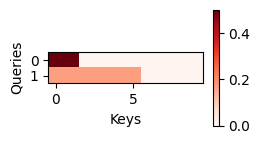

In [7]:
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
              xlabel='Keys', ylabel='Queries')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel=&#x27;Keys&#x27;, ylabel=&#x27;Queries&#x27;)
    </pre>
  </div>
</details>

## 10.3.4.缩放点积注意力

使用点积可以得到计算效率更高的评分函数，但是点积操作要求查询和键具有相同的长度$d$。假设查询和键的所有元素都是独立的随机变量，并且都满足零均值和单位方差，那么两个向量的点积的均值为$0$，方差为$d$。为确保无论向量长度如何，点积的方差在不考虑向量长度的情况下仍然是$1$，我们再将点积除以$\sqrt{d}$，则*缩放点积注意力*（scaled dot-product attention）评分函数为：

$$a(\mathbf q, \mathbf k) = \mathbf{q}^\top \mathbf{k}  /\sqrt{d}. \tag{10.3.4}$$

在实践中，我们通常从小批量的角度来考虑提高效率，例如基于$n$个查询和$m$个键－值对计算注意力，其中查询和键的长度为$d$，值的长度为$v$。查询$\mathbf Q\in\mathbb R^{n\times d}$、键$\mathbf K\in\mathbb R^{m\times d}$和值$\mathbf V\in\mathbb R^{m\times v}$的缩放点积注意力是：

$$ \mathrm{softmax}\left(\frac{\mathbf Q \mathbf K^\top }{\sqrt{d}}\right) \mathbf V \in \mathbb{R}^{n\times v}. \tag{10.3.5}$$

下面的缩放点积注意力的实现使用了暂退法进行模型正则化。两个小批量矩阵乘法（`queries @ keys^T` 与 `attention_weights @ values`）均使用 `PyPTOBMM`；注意 `keys.transpose(1, 2)` 产生非连续张量，`PyPTOBMM` 内部已做 `contiguous()` 处理。

In [8]:
class DotProductAttention(nn.Module):
    """缩放点积注意力（PyPTO 算子版）"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries的形状：(batch_size，查询的个数，d)
    # keys的形状：(batch_size，"键－值"对的个数，d)
    # values的形状：(batch_size，"键－值"对的个数，值的维度)
    # valid_lens的形状:(batch_size，)或者(batch_size，查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b=True为了交换keys的最后两个维度
        scores = PyPTOBMM.apply(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;">本处保持<b>分解式</b>实现（QK<sup>ᵀ</sup> → 缩放 → softmax → PV 逐步可见），便于理解评分函数到注意力权重的完整流程；其中 <code>bmm</code> 已使用优化后的 <code>PyPTOBMM</code>（2D loop+view，见 10.2.5 节）。</li>
      <li style="margin: 0 0 8px 0;">收录版 <code>src/attention.py</code> 的 <code>DotProductAttention</code> 在此基础上增加了<b>融合路径</b>：当 <code>valid_lens is None</code> 且无 dropout 时，QK<sup>ᵀ</sup>+softmax+PV 在单个 kernel 内完成（(512,10,64) 单卡实测前向约快 13 倍），<code>attention_weights</code> 由 kernel 输出的 softmax 概率提供，可视化行为不变；带掩码或有 dropout 时自动回退到本处的分解实现。融合写法参考 pypto 官方仓库（gitcode.com/cann/pypto）的 <code>examples/03_advanced/advanced_nn/attention/attention.py</code>。</li>
      <li style="margin: 0 0 8px 0;"><b>训练场景注意</b>：融合路径仅在无掩码且无 dropout 时生效；10.7 节 Transformer 训练中注意力均带掩码（<code>valid_lens</code>）与 dropout，走的是本处分解实现——其提速来自优化后的 <code>PyPTOBMM</code>（2D loop+view，约 12 倍）与 softmax 行 tile（约 5 倍），而非融合 kernel。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
class DotProductAttention(nn.Module):
    &quot;&quot;&quot;缩放点积注意力&quot;&quot;&quot;
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
    # queries的形状：(batch_size，查询的个数，d)
    # keys的形状：(batch_size，&quot;键－值&quot;对的个数，d)
    # values的形状：(batch_size，&quot;键－值&quot;对的个数，值的维度)
    # valid_lens的形状:(batch_size，)或者(batch_size，查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b=True为了交换keys的最后两个维度
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)
    </pre>
  </div>
</details>


为了**演示上述的`DotProductAttention`类**，我们使用与先前加性注意力例子中相同的键、值和有效长度。对于点积操作，我们令查询的特征维度与键的特征维度大小相同。

In [9]:
queries = torch.normal(0, 1, (2, 1, 2), device=device)
attention = DotProductAttention(dropout=0.5).to(device)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], device='npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)
    </pre>
  </div>
</details>

与加性注意力演示相同，由于键包含的是相同的元素，而这些元素无法通过任何查询进行区分，因此获得了**均匀的注意力权重**。

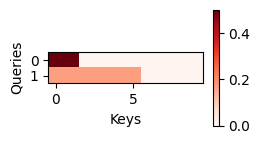

In [10]:
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
              xlabel='Keys', ylabel='Queries')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel=&#x27;Keys&#x27;, ylabel=&#x27;Queries&#x27;)
    </pre>
  </div>
</details>

## 10.3.5.小结

* 将注意力汇聚的输出计算可以作为值的加权平均，选择不同的注意力评分函数会带来不同的注意力汇聚操作。
* 当查询和键是不同长度的矢量时，可以使用可加性注意力评分函数。当它们的长度相同时，使用缩放的"点－积"注意力评分函数的计算效率更高。

## 10.3.6.练习

1. 修改小例子中的键，并且可视化注意力权重。可加性注意力和缩放的"点－积"注意力是否仍然产生相同的结果？为什么？
1. 只使用矩阵乘法，能否为具有不同矢量长度的查询和键设计新的评分函数？
1. 当查询和键具有相同的矢量长度时，矢量求和作为评分函数是否比"点－积"更好？为什么？

参考答案详见 [answers/10.03_reference_answer](./answers/10.03_reference_answer.ipynb)。

### 10.3.6.1.参考答案（PyPTO）

In [11]:
!cat answers/txt/10.03_reference_answer_pypto.txt

### 10.3.6.2.参考答案（PyTorch）

In [12]:
!cat answers/txt/10.03_reference_answer_pytorch.txt